In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

In [2]:
path = kagglehub.dataset_download("sulianova/cardiovascular-disease-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\pirom\.cache\kagglehub\datasets\sulianova\cardiovascular-disease-dataset\versions\1


In [3]:
df=pd.read_csv(f'{path}\\cardio_train.csv',sep=';')
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [5]:
df.isna().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['fecha_nacimiento'] = pd.to_datetime(
    df['age'], unit='D', origin='1899-12-30'
)
df['fecha_nacimiento'].head()

0   1950-05-10
1   1955-05-19
2   1951-08-17
3   1948-03-31
4   1947-11-03
Name: fecha_nacimiento, dtype: datetime64[s]

In [9]:
df['edad'] = (df['age'] / 365.25).astype(int)
df = df.drop(['age'], axis=1)

In [10]:
df = df[
    (df['ap_hi'] >= 80) & (df['ap_hi'] <= 220) &
    (df['ap_lo'] >= 40) & (df['ap_lo'] <= 130)
]

df = df[df['ap_hi'] > df['ap_lo']]
df.reset_index()

,index,id,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,fecha_nacimiento,edad
0,0,0,2,168,62.0,110,80,1,1,0,0,1,0,1950-05-10,50
1,1,1,1,156,85.0,140,90,3,1,0,0,1,1,1955-05-19,55
2,2,2,1,165,64.0,130,70,3,1,0,0,0,1,1951-08-17,51
3,3,3,2,169,82.0,150,100,1,1,0,0,1,1,1948-03-31,48
4,4,4,1,156,56.0,100,60,1,1,0,0,0,0,1947-11-03,47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68634,69995,99993,2,168,76.0,120,80,1,1,1,0,1,0,1952-09-03,52
68635,69996,99995,1,158,126.0,140,90,2,2,0,0,1,1,1961-11-16,61
68636,69997,99996,2,183,105.0,180,90,3,1,0,1,0,1,1952-03-13,52
68637,69998,99998,1,163,72.0,135,80,1,2,0,0,0,1,1961-05-30,61


In [11]:
df['imc']=df['weight']/((df['height']/100)**2)

In [12]:
df['tipo_de_presion'] = 'bajo'

df.loc[(df['ap_hi'] > 140) & (df['ap_lo'] > 100), 'tipo_de_presion'] = 'alto'
df.loc[(df['ap_hi'] > 90) & (df['ap_lo'] > 60), 'tipo_de_presion'] = 'normal'

In [13]:
df_cardiovascular=df[df['cardio']==1]

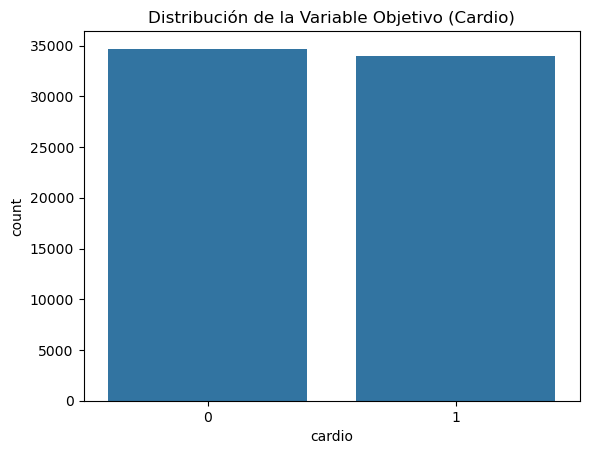

cardio
0    0.505412
1    0.494588
Name: proportion, dtype: float64


In [14]:
sns.countplot(x='cardio', data=df)
plt.title("Distribución de la Variable Objetivo (Cardio)")
plt.show()
print(df['cardio'].value_counts(normalize=True))

se puede observar que el dataset esta equilibrado con casi la misma cantidad de enfermos del corazon y no

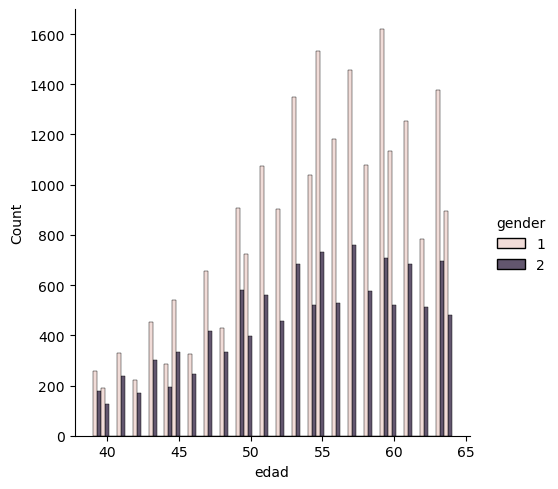

In [15]:
sns.displot(df_cardiovascular, x="edad", hue="gender", multiple="dodge")

se puede observar que el comportamiento de las enfermedades del corazon es muy similar entre hombres y mujeres

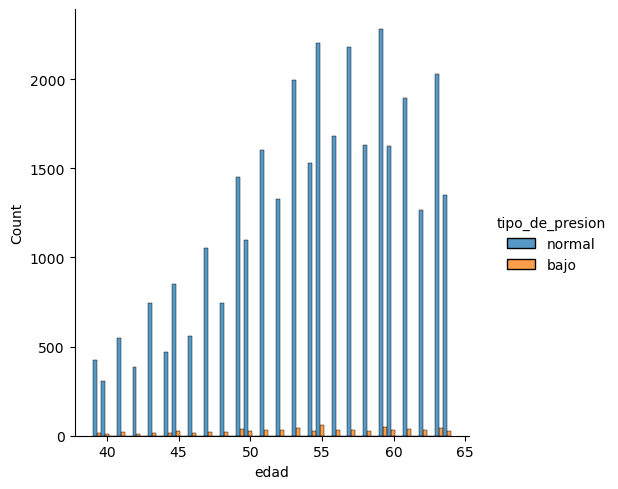

In [16]:
sns.displot(df_cardiovascular, x="edad", hue="tipo_de_presion", multiple="dodge")

se puede observar que el comportamiento de las enfermedades del corazon tiene una gran correlacion con la presion

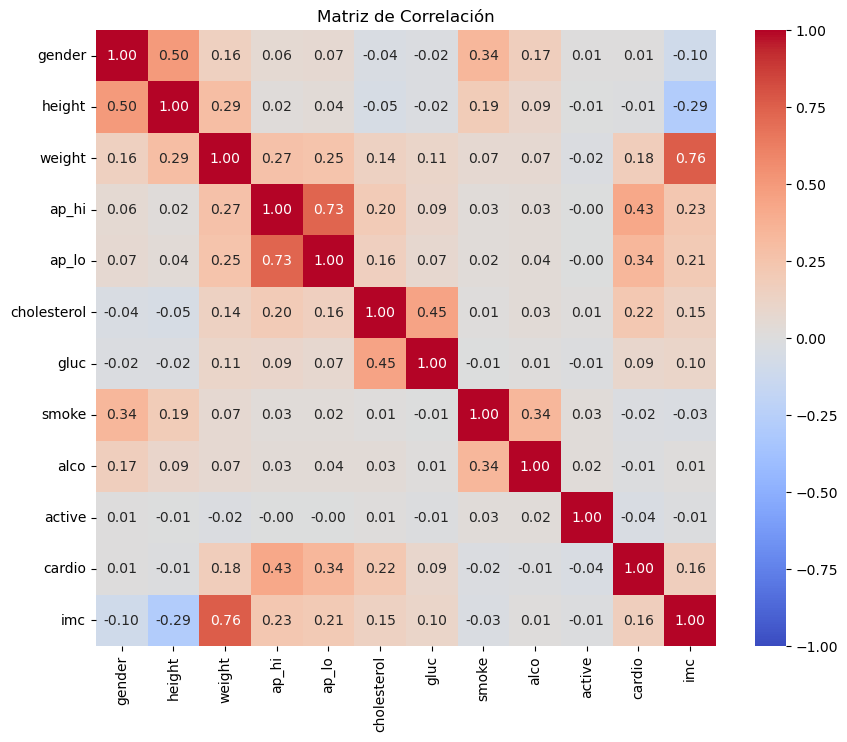

In [17]:
df_sin_fecha=df.drop(['id','fecha_nacimiento','tipo_de_presion','edad'],axis=1)

corr_matrix = df_sin_fecha.corr()

plt.figure(figsize=(10, 8))


sns.heatmap(
    corr_matrix, 
    annot=True,     
    cmap='coolwarm',
    fmt=".2f",       
    vmin=-1, vmax=1  
)

plt.title('Matriz de Correlación')
plt.show()

In [18]:
df['tipo_de_presion'] = pd.factorize(df['tipo_de_presion'])[0]
df['tipo_de_presion'].value_counts()

tipo_de_presion
0    65643
1     2996
Name: count, dtype: int64

In [19]:
from sklearn.model_selection import train_test_split
X=df.drop(['cardio','fecha_nacimiento','id',],axis=1)
y=df['cardio']
# 1. Divide tus datos PRIMERO
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
num_cols = ['height', 'weight', 'ap_hi', 'ap_lo', 'imc']

preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), num_cols) 
    ],
    remainder='passthrough'
)


X_train_scaled_array = preprocessor.fit_transform(X_train)


X_test_scaled_array = preprocessor.transform(X_test)


columnas_ordenadas = num_cols + [col for col in X.columns if col not in num_cols]

X_train = pd.DataFrame(X_train_scaled_array, columns=columnas_ordenadas, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled_array, columns=columnas_ordenadas, index=X_test.index)

# ¡Listo! Ya puedes usar X_train_scaled para entrenar tu modelo
print("¡Datos escalados con éxito!")

¡Datos escalados con éxito!


In [21]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the classifier with 100 trees
clf = RandomForestClassifier()

# Train the model
clf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [22]:
y_pred = clf.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
matriz = confusion_matrix(y_test, y_pred)

print('accuracy = ',accuracy)
print('precision = ',precision)
print('recall = ', recall)
print('f1 = ',f1)
print('matriz = ',matriz)

accuracy =  0.7118298368298368
precision =  0.7075612671846981
recall =  0.7031482031482031
f1 =  0.7053478325636824
matriz =  [[5037 1957]
 [1999 4735]]


In [24]:
import xgboost as xgb
model_xgb = xgb.XGBClassifier()
model_xgb.fit(X_train, y_train)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [25]:
y_pred_xgb = model_xgb.predict(X_test)

In [26]:
accuracy = accuracy_score(y_test, y_pred_xgb)
precision = precision_score(y_test, y_pred_xgb)
recall = recall_score(y_test, y_pred_xgb)
f1 = f1_score(y_test, y_pred_xgb)
matriz = confusion_matrix(y_test, y_pred_xgb)

print('accuracy = ',accuracy)
print('precision = ',precision)
print('recall = ', recall)
print('f1 = ',f1)
print('matriz = ',matriz)

accuracy =  0.7381264568764568
precision =  0.7499601847427935
recall =  0.6992871992871993
f1 =  0.7237378006608776
matriz =  [[5424 1570]
 [2025 4709]]


In [27]:
import lightgbm as lgb
model_lgb = lgb.LGBMClassifier()
model_lgb.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 27214, number of negative: 27697
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001503 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 698
[LightGBM] [Info] Number of data points in the train set: 54911, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.495602 -> initscore=-0.017593
[LightGBM] [Info] Start training from score -0.017593


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [28]:
y_pred_lgb = model_lgb.predict(X_test)

In [29]:
accuracy = accuracy_score(y_test, y_pred_lgb)
precision = precision_score(y_test, y_pred_lgb)
recall = recall_score(y_test, y_pred_lgb)
f1 = f1_score(y_test, y_pred_lgb)
matriz = confusion_matrix(y_test, y_pred_lgb)

print('accuracy = ',accuracy)
print('precision = ',precision)
print('recall = ', recall)
print('f1 = ',f1)
print('matriz = ',matriz)

accuracy =  0.7390734265734266
precision =  0.7507956715467855
recall =  0.7006237006237006
f1 =  0.7248425257335996
matriz =  [[5428 1566]
 [2016 4718]]


In [30]:
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2],
    'min_child_weight': [1, 3, 5]
}

In [31]:
from sklearn.model_selection import RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=model_xgb,
    param_distributions=param_dist,
    n_iter=20,  
    scoring='recall',
    cv=5,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

In [32]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ate=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here...

In [33]:

from sklearn.metrics import roc_auc_score
best_model = random_search.best_estimator_

y_proba = best_model.predict_proba(X_test)[:, 1]

y_pred = (y_proba > 0.3).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
matriz = confusion_matrix(y_test, y_pred)
roc_auc=roc_auc_score(y_test, y_proba)

print('accuracy = ',accuracy)
print('precision = ',precision)
print('recall = ', recall)
print('f1 = ',f1)
print('roc_auc = ',roc_auc)
print('matriz = ',matriz)

accuracy =  0.6826923076923077
precision =  0.625
recall =  0.8828333828333829
f1 =  0.7318724609134556
roc_auc =  0.8054919936890197
matriz =  [[3427 3567]
 [ 789 5945]]


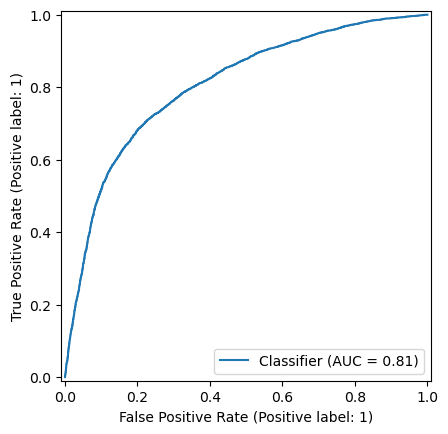

In [34]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, y_proba)

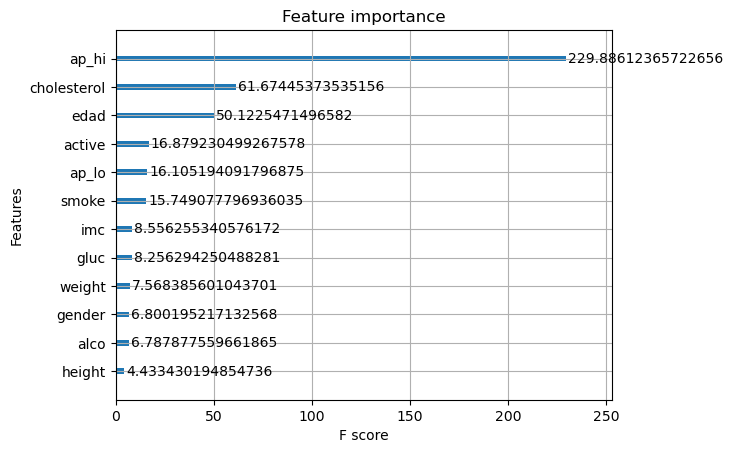

In [35]:
xgb.plot_importance(best_model, importance_type='gain')
plt.show()

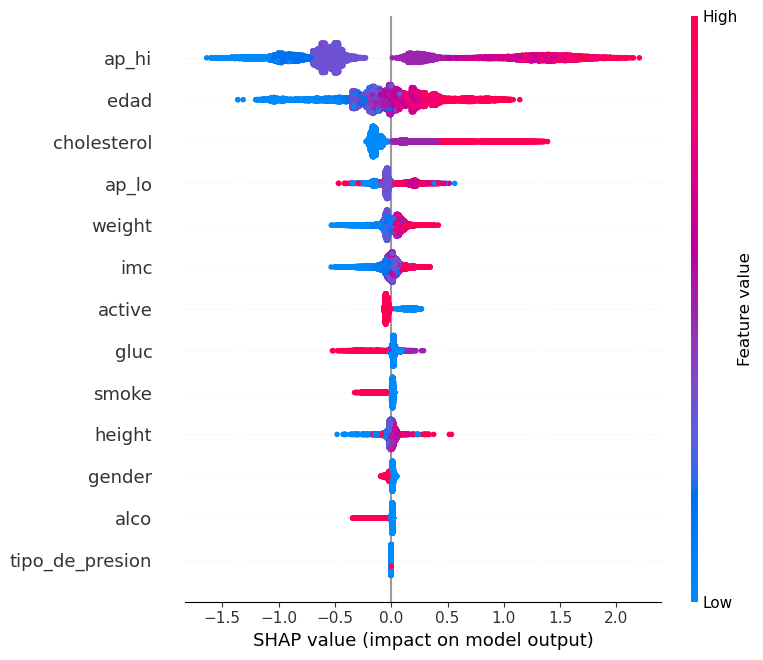

In [36]:
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)